## Unemployment in India

In [5]:
import pandas as pd
df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\OASIS INTERNSHIP\Unemployment in India.csv')
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (768, 7)


In [7]:
print("Null values per column:")
display(df.isnull().sum())

Null values per column:


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
print("Data types of each column:")
display(df.info())

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


None

In [9]:
df.columns = df.columns.str.strip()
print("Cleaned column names:")
display(df.columns)

Cleaned column names:


Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [10]:
initial_rows = df.shape[0]
df.dropna(inplace=True)
print(f"Dropped {initial_rows - df.shape[0]} rows with null values.")
print(f"New shape of the DataFrame: {df.shape}")
print("Null values after dropping:")
display(df.isnull().sum())

Dropped 28 rows with null values.
New shape of the DataFrame: (740, 7)
Null values after dropping:


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print("Data types after 'Date' conversion:")
display(df.info())

Data types after 'Date' conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


None

In [12]:
print("First 5 rows of the transformed DataFrame:")
display(df.head())

First 5 rows of the transformed DataFrame:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## Data Loading and Cleaning: Loaded the data, inspected its shape, checked for null values, cleaned column names, handled missing values, and converted the 'Date' column to the correct datetime format.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\sumit\AppData\Local\Temp\ipykernel_21336\3881679842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')


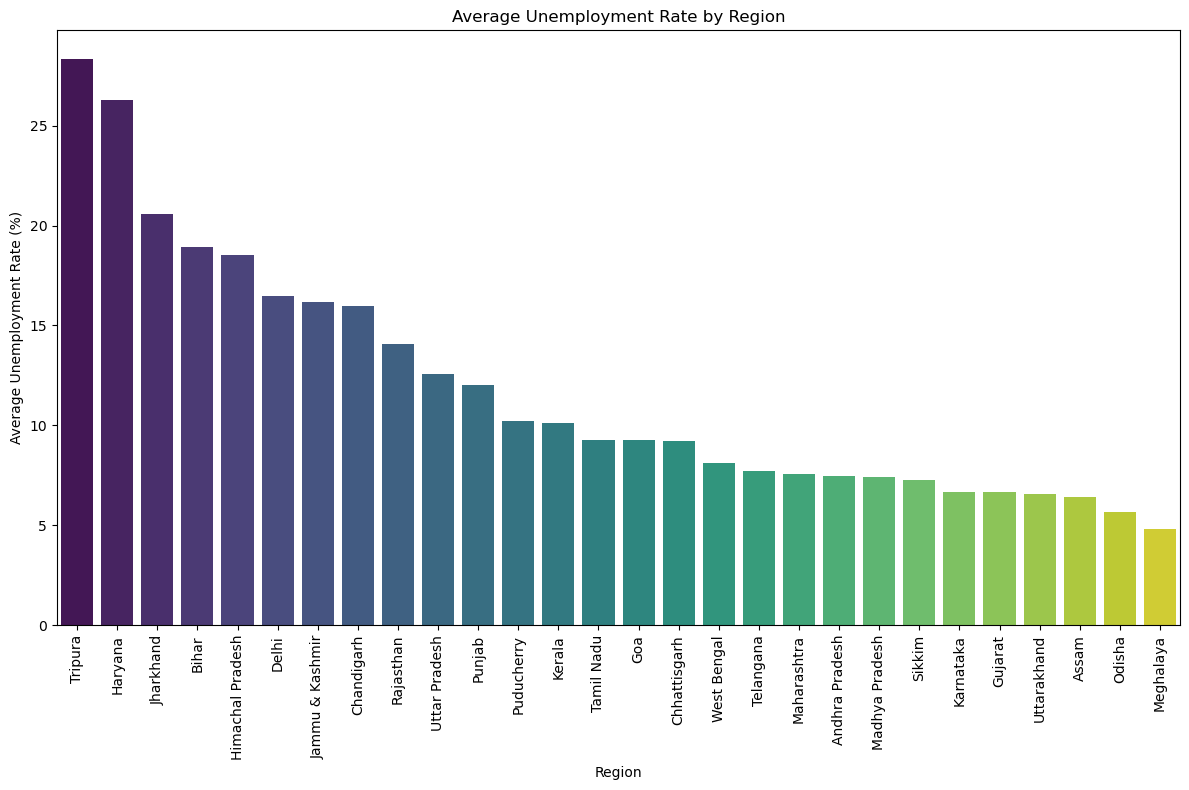

In [15]:
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate by Region')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA): Visualized region-wise average unemployment rates.

C:\Users\sumit\AppData\Local\Temp\ipykernel_21336\307460529.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=month_unemployment.index, y=month_unemployment.values, marker='o', palette='deep')


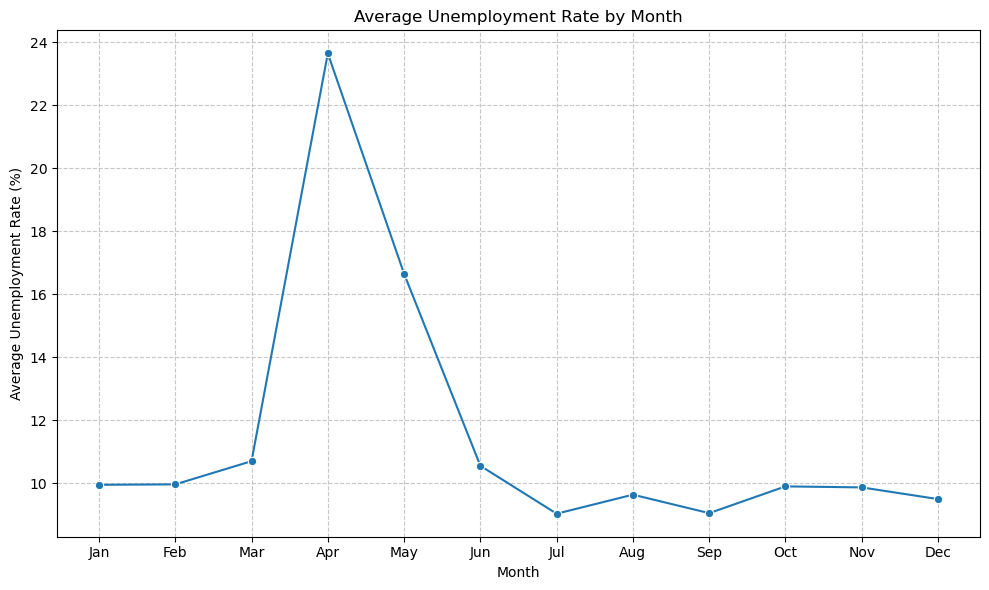

In [16]:
df['Month'] = df['Date'].dt.month
month_unemployment = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=month_unemployment.index, y=month_unemployment.values, marker='o', palette='deep')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate by Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyzed month-wise unemployment trends.

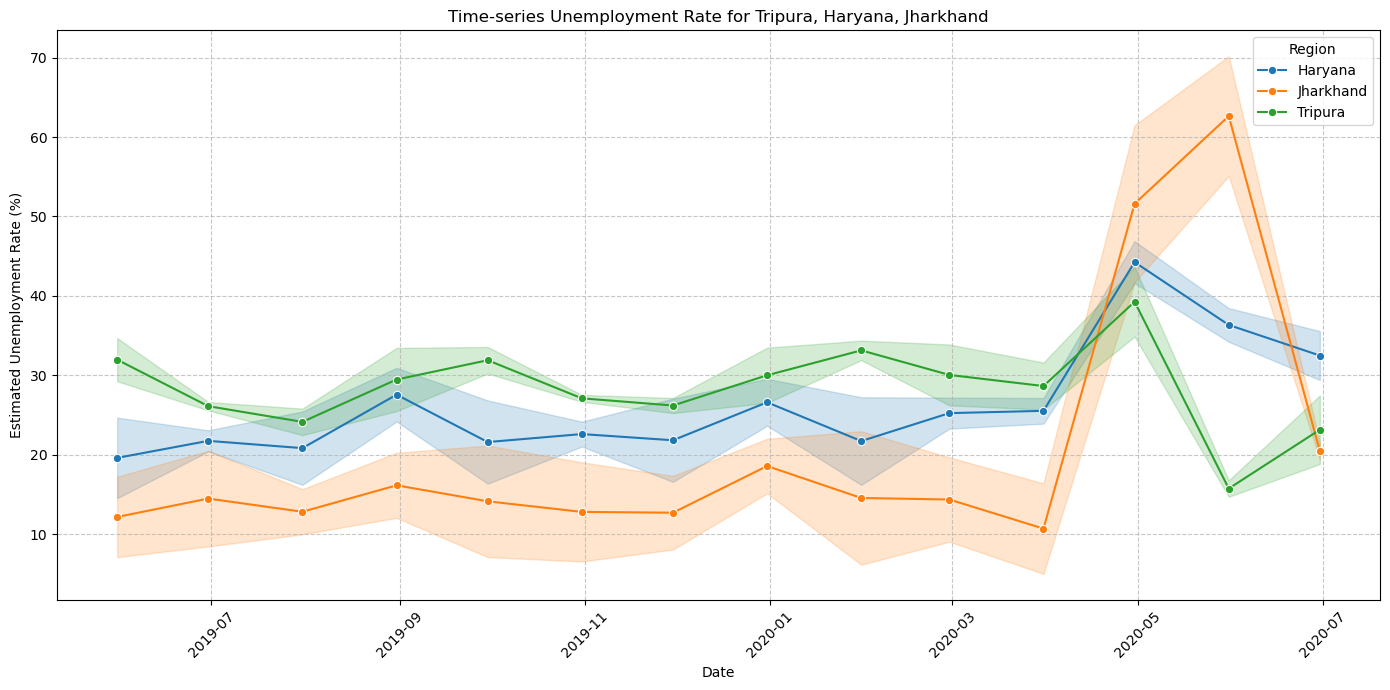

In [17]:
# Select top 3 regions with highest unemployment for time-series analysis
top_regions = region_unemployment.head(3).index.tolist()

# Filter the DataFrame for these regions
df_top_regions = df[df['Region'].isin(top_regions)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top_regions, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title(f'Time-series Unemployment Rate for {', '.join(top_regions)}')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plotted time-series unemployment rates for the top 3 major regions (Tripura, Haryana, Jharkhand).

C:\Users\sumit\AppData\Local\Temp\ipykernel_21336\2960576710.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_regions_unemployment.index, y=top_10_regions_unemployment.values, palette='magma')


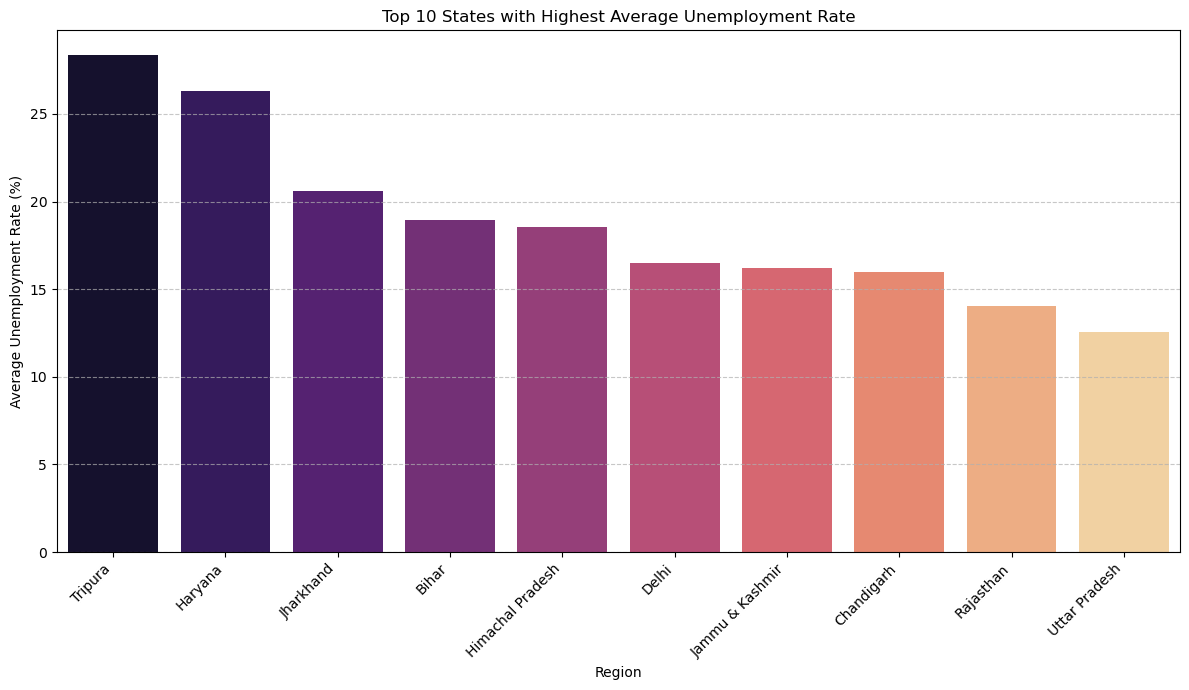

In [18]:
# Select the top 10 regions with the highest average unemployment rate
top_10_regions_unemployment = region_unemployment.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_regions_unemployment.index, y=top_10_regions_unemployment.values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Generated a bar chart for the top 10 states with the highest average unemployment rate.

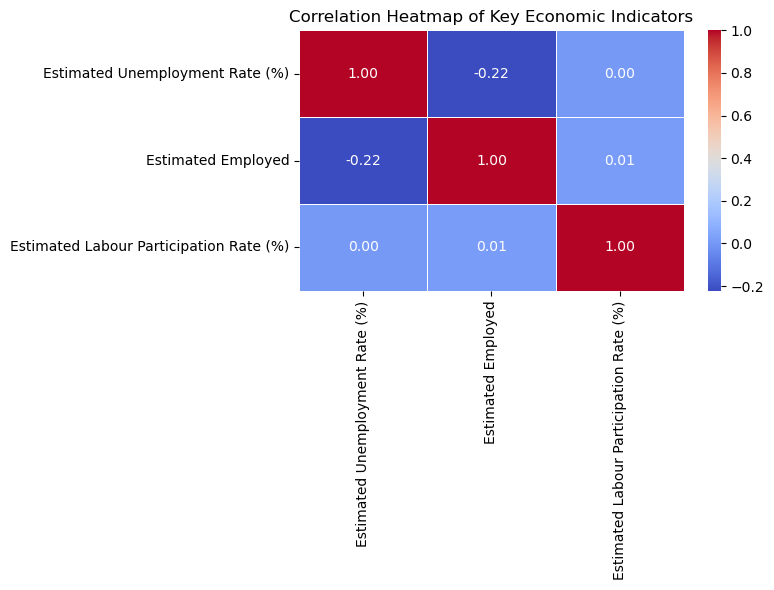

In [19]:
correlation_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Key Economic Indicators')
plt.tight_layout()
plt.show()

## Created a heatmap showing the correlation between unemployment rate, employment rate, and labor participation rate.

In [20]:
# Define a cutoff date for pre-COVID vs. post-COVID (e.g., end of March 2020)
covid_cutoff_date = pd.to_datetime('2020-03-31')

# Split the DataFrame into pre-COVID and post-COVID periods
df_pre_covid = df[df['Date'] <= covid_cutoff_date]
df_post_covid = df[df['Date'] > covid_cutoff_date]

# Select the metrics for comparison
metrics = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

# Calculate the mean for each metric in both periods
mean_pre_covid = df_pre_covid[metrics].mean()
mean_post_covid = df_post_covid[metrics].mean()

# Combine into a single DataFrame for easier comparison
comparison_df = pd.DataFrame({
    'Pre-COVID Mean': mean_pre_covid,
    'Post-COVID Mean': mean_post_covid
})

print("Comparison of Key Economic Indicators (Pre-COVID vs. Post-COVID):")
display(comparison_df)

Comparison of Key Economic Indicators (Pre-COVID vs. Post-COVID):


,Pre-COVID Mean,Post-COVID Mean
Estimated Unemployment Rate (%),9.614864e+00,2.019434e+01
Estimated Employed,7.470499e+06,6.175311e+06
Estimated Labour Participation Rate (%),4.381519e+01,3.804579e+01


## Pre-COVID vs. Post-COVID Comparison: Split the data and compared key economic indicators before and after the defined COVID-19 cutoff date, highlighting the significant impact on unemployment, employment, and labor participation rates.